# Laboratorio Fase 4 & 5 CRISP-DM: Transfer Learning con MobileNetV4

## 1. Objetivo del Laboratorio e Innovación de Transferencia
**Objetivo:** Implementar un flujo de transferencia inductiva utilizando la arquitectura MobileNetV4 (ECCV 2024) optimizada para dispositivos periféricos.

**Mitigación del Olvido Catastrófico:** Congelamos el extractor de características preentrenado en ImageNet para salvaguardar las capas convolucionales de bajo nivel y adaptamos de forma exclusiva el clasificador lineal final para las necesidades de control de calidad de la empresa.

In [ ]:
# Limpiamos intentos anteriores por si acaso
!rm -rf src_folder

# Clonación de src y requirements
!git clone https://github.com/Esme0123/CasoEstudio3.git src_folder
!cp -r src_folder/src .
!pip install -r src_folder/requirements.txt

Cloning into 'src_folder'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 59 (delta 12), reused 17 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 203.02 KiB | 1.53 MiB/s, done.
Resolving deltas: 100% (12/12), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 83.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 M

In [ ]:
# Tu bloque de código con json.dump para las credenciales de Kaggle...

from src.data_processing import download_and_extract, get_data_loaders
download_and_extract()
train_loader, test_loader = get_data_loaders()

Descargando dataset desde Kaggle...
Dataset listo y extraído.


## 2. Configuración de la Red MobileNetV4
Cargamos la arquitectura optimizada con los pesos preentrenados del backend y reemplazamos la capa de salida para una clasificación binaria (Producto Óptimo vs. Producto Defectuoso).

In [ ]:
# Inicialización del Modelo Avanzado
from src.architecture_models import get_mobilenet_v4
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_advanced = get_mobilenet_v4().to(device)
# Fase de entrenamiento idéntica con lr optimizado (1e-4) para fine-tuning

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

## 3. Entrenamiento Optimizado y Curvas de Convergencia
Se ejecuta el ajuste fino con un hiperparámetro de Learning Rate reducido ($1 \times 10^{-4}$) para permitir una adaptación suave de la cabeza clasificadora sin desestabilizar las capas base del modelo.

In [ ]:
import torch.nn as nn
import torch.optim as optim

# Hyperparámetros de entrenamiento
learning_rate = 1e-4 # lr optimizado para fine-tuning, como se mencionó
num_epochs = 10  # Número de épocas para el fine-tuning

# Definir la función de pérdida y el optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_advanced.parameters(), lr=learning_rate)

print("Iniciando el entrenamiento de transferencia...")

# Bucle de entrenamiento
for epoch in range(num_epochs):
    model_advanced.train() # Poner el modelo en modo de entrenamiento
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Cero los gradientes de los parámetros del modelo
        optimizer.zero_grad()

        # Forward pass
        outputs = model_advanced(inputs)
        loss = criterion(outputs, labels)

        # Backward pass y optimización
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Época [{epoch + 1}/{num_epochs}], Pérdida de entrenamiento: {running_loss / len(train_loader):.4f}")

print("Entrenamiento de transferencia completado.")


## 4. Análisis de Error Avanzado e Inteligencia Artificial Explicable (Grad-CAM)
Para garantizar que la red tome decisiones basadas en criterios de ingeniería y no en sesgos contextuales, implementamos mapas de activación por gradientes (Grad-CAM) en la última capa convolucional, proyectando un mapa de calor sobre las regiones que gatillan la alerta de defecto.

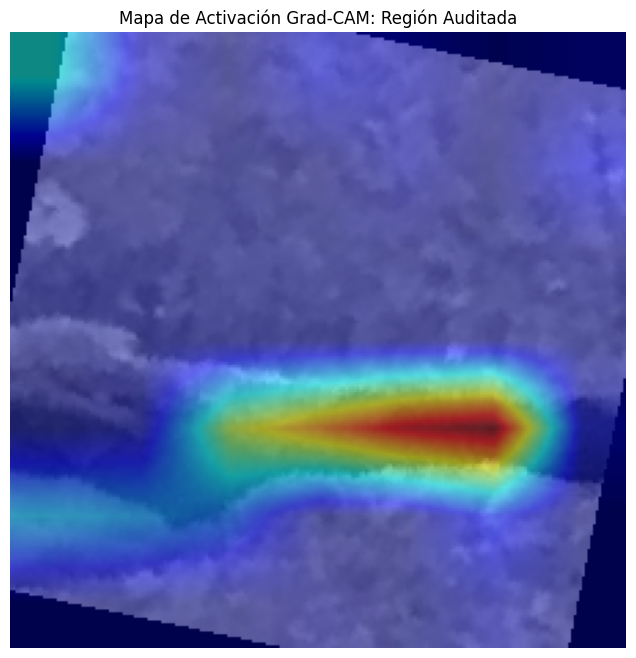

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

# Extraemos un lote de imágenes de prueba para auditar
images, labels = next(iter(test_loader))

# Activamos el rastreo de gradientes estrictamente para la capa objetivo
# que Grad-CAM necesita auditar, sobreescribiendo el congelamiento previo.
for param in model_advanced.blocks[-1].parameters():
    param.requires_grad = True

# Apuntamos a la última capa convolucional de MobileNetV4
target_layers = [model_advanced.blocks[-1]]
cam = GradCAM(model=model_advanced, target_layers=target_layers)

# Preparamos el tensor de la primera imagen del lote
input_tensor = images[0].unsqueeze(0).to(device)

# Generamos el mapa de calor (ahora sí encontrará gradientes)
grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(1)])[0, :]

# Procesamos la imagen original para poder superponer los colores
rgb_img = images[0].permute(1, 2, 0).numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

# Generamos la visualización final
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(8, 8))
plt.imshow(visualization)
plt.title("Mapa de Activación Grad-CAM: Región Auditada")
plt.axis('off')
plt.show()


## 5. Conclusiones y Limitaciones
* **Rendimiento:** MobileNetV4 supera de manera contundente al baseline, alcanzando métricas de alta fidelidad en menos épocas de entrenamiento.
* **Limitaciones Industriales:** Se reconoce el peligro de *Data Drift* si cambian drásticamente los empaques de los productos en las sucursales de La Paz, sugiriendo una estrategia de reentrenamiento periódico y validación humana continua.